In [1]:
import pandas as pd
import os

# Choose one file
file_path = r"C:\Users\kamal\Downloads\MachineLearningCSV\MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Original Shape:", df.shape)

# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Fix Label column
if ' Label' in df.columns:
    df.rename(columns={' Label': 'Label'}, inplace=True)

# 3. Check missing values
print("Missing Values:", df.isnull().sum().sum())

# 4. Drop duplicates
df = df.drop_duplicates()

# 5. Drop irrelevant columns (same for all files)
drop_cols = ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

print("Shape after cleaning:", df.shape)
print("\nLabel Distribution:")
print(df['Label'].value_counts())

# Save cleaned version
os.makedirs("03_Data/processed", exist_ok=True)
df.to_csv("03_Data/processed/cleaned_ddos.csv", index=False)

print("✅ First file cleaned and saved!")

Original Shape: (225745, 79)
Missing Values: 4
Shape after cleaning: (223112, 79)

Label Distribution:
Label
DDoS      128016
BENIGN     95096
Name: count, dtype: int64
✅ First file cleaned and saved!


In [4]:
df.head(2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
import pandas as pd
import glob
import os

data_dir = "/home/workdir/attachments/"
processed_dir = "03_Data/processed/"
os.makedirs(processed_dir, exist_ok=True)

csv_files = glob.glob(data_dir + "*.csv")

for file in csv_files:
    filename = os.path.basename(file)
    print(f"Processing: {filename}")
    
    df = pd.read_csv(file, low_memory=False)
    
    # Cleaning
    df.columns = df.columns.str.strip()
    if ' Label' in df.columns:
        df.rename(columns={' Label': 'Label'}, inplace=True)
    
    df = df.drop_duplicates()
    
    drop_cols = ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')
    
    # Save each cleaned file
    clean_name = "cleaned_" + filename
    df.to_csv(processed_dir + clean_name, index=False)
    print(f"  → Saved: {clean_name} | Shape: {df.shape}")

print("\n✅ All files cleaned individually!")

In [5]:
import pandas as pd
import glob
import os

# List all CSV files in current directory
csv_files = glob.glob("*.csv")
print("Found", len(csv_files), "CSV files:")
for f in csv_files:
    print(" -", f)

# Load and combine
all_dfs = []
for file in csv_files:
    print("Loading:", file)
    df = pd.read_csv(file, low_memory=False)
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
print("\nCombined Shape:", combined.shape)

# Cleaning
combined.columns = combined.columns.str.strip()
if ' Label' in combined.columns:
    combined.rename(columns={' Label': 'Label'}, inplace=True)

combined = combined.drop_duplicates()

drop_cols = ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp']
combined = combined.drop(columns=[col for col in drop_cols if col in combined.columns], errors='ignore')

print("Shape after cleaning:", combined.shape)
print("\nLabel Distribution:")
print(combined['Label'].value_counts())

# Save
os.makedirs("03_Data/processed", exist_ok=True)
combined.to_csv("03_Data/processed/combined_cleaned_data.csv", index=False)

print("✅ All files combined and cleaned successfully!")

Found 8 CSV files:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

Combined Shape: (2830743, 79)
Shape after cleaning: (2522362, 79)

Label Distribution:
Label
BENIGN                        2096484
DoS Hulk               

Dataset Shape: (2522362, 79)

Label Distribution:
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


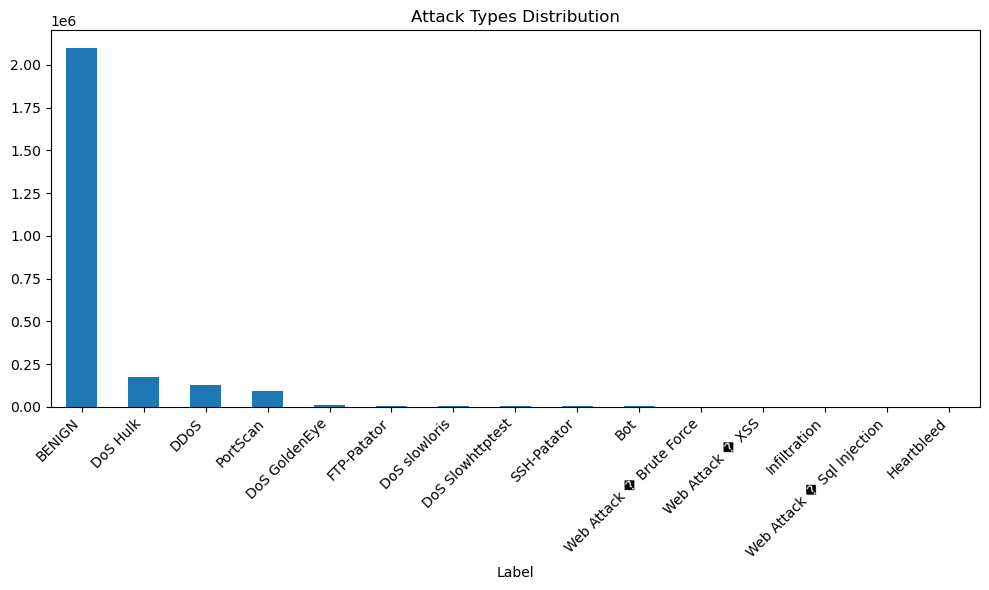

KeyError: 'Label'

<Figure size 1200x1000 with 0 Axes>

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load combined data
df = pd.read_csv("03_Data/processed/combined_cleaned_data.csv", low_memory=False)

print("Dataset Shape:", df.shape)
print("\nLabel Distribution:")
print(df['Label'].value_counts())

# 1. Class Distribution Plot
plt.figure(figsize=(10,6))
df['Label'].value_counts().plot(kind='bar')
plt.title("Attack Types Distribution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Top features)
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(12,10))
top_features = corr['Label'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(corr.loc[top_features, top_features], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Top 15 Features")
plt.show()

# 3. Save plots
plt.savefig("05_Results/class_distribution.png")
plt.savefig("05_Results/correlation_heatmap.png")

print(" EDA Plots created!")

In [15]:
df['Label']

0          BENIGN
1          BENIGN
2          BENIGN
3          BENIGN
4          BENIGN
            ...  
2522357    BENIGN
2522358    BENIGN
2522359    BENIGN
2522360    BENIGN
2522361    BENIGN
Name: Label, Length: 2522362, dtype: object

E:\sql\anconda\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
E:\sql\anconda\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
E:\sql\anconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
E:\sql\anconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


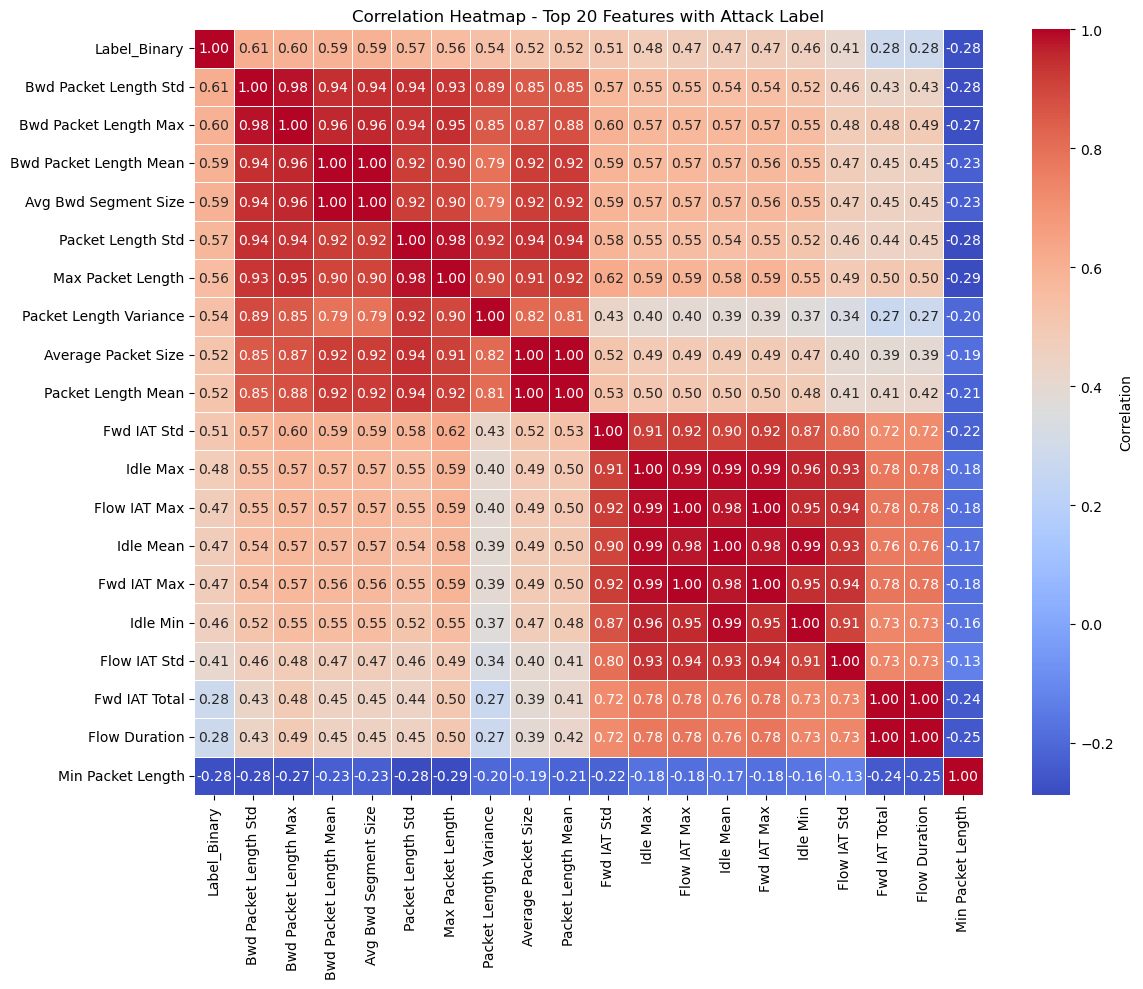

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include=['number']).copy()

# Compute correlation with Label (binary)
# First convert Label to binary for correlation
df['Label_Binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Get top correlated features
corr_with_label = numeric_df.corrwith(df['Label_Binary']).abs().sort_values(ascending=False)
top_features = corr_with_label.head(20).index.tolist()

# Plot heatmap
plt.figure(figsize=(12, 10))
corr_matrix = numeric_df[top_features].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap - Top 20 Features with Attack Label")
plt.tight_layout()
plt.show()

# Save
#plt.savefig("05_Results/correlation_heatmap_top20.png", dpi=300)

Shape: (80000, 79)
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10278
           1       1.00      1.00      1.00     13722

    accuracy                           1.00     24000
   macro avg       1.00      1.00      1.00     24000
weighted avg       1.00      1.00      1.00     24000


Top 15 Important Features:
                        Feature  Importance
6         Fwd Packet Length Max    0.105665
63            Subflow Fwd Bytes    0.084791
66       Init_Win_bytes_forward    0.080487
62          Subflow Fwd Packets    0.063261
21                 Fwd IAT Mean    0.048533
68             act_data_pkt_fwd    0.048464
53         Avg Fwd Segment Size    0.047659
4   Total Length of Fwd Packets    0.046649
20                Fwd IAT Total    0.046497
22                  Fwd IAT Std    0.044895
8        Fwd Packet Length Mean    0.042238
34            Fwd Header Length    0.036065
54         Avg Bwd Segment Size

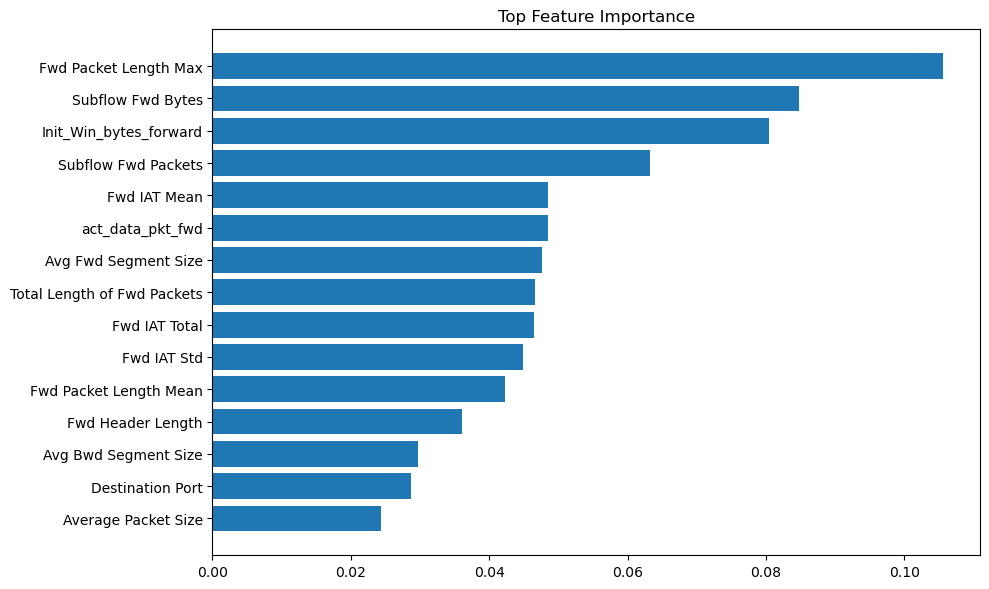

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load
df = pd.read_csv("03_Data/processed/cleaned_ddos.csv", low_memory=True, nrows=80000)

print("Shape:", df.shape)

df.columns = df.columns.str.strip()
df.rename(columns={' Label': 'Label'}, inplace=True)

# Critical: Replace inf and very large values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

df['Label_Binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.select_dtypes(include=['number']).drop(columns=['Label_Binary'], errors='ignore')
y = df['Label_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

print("\nTop 15 Important Features:")
print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Top Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

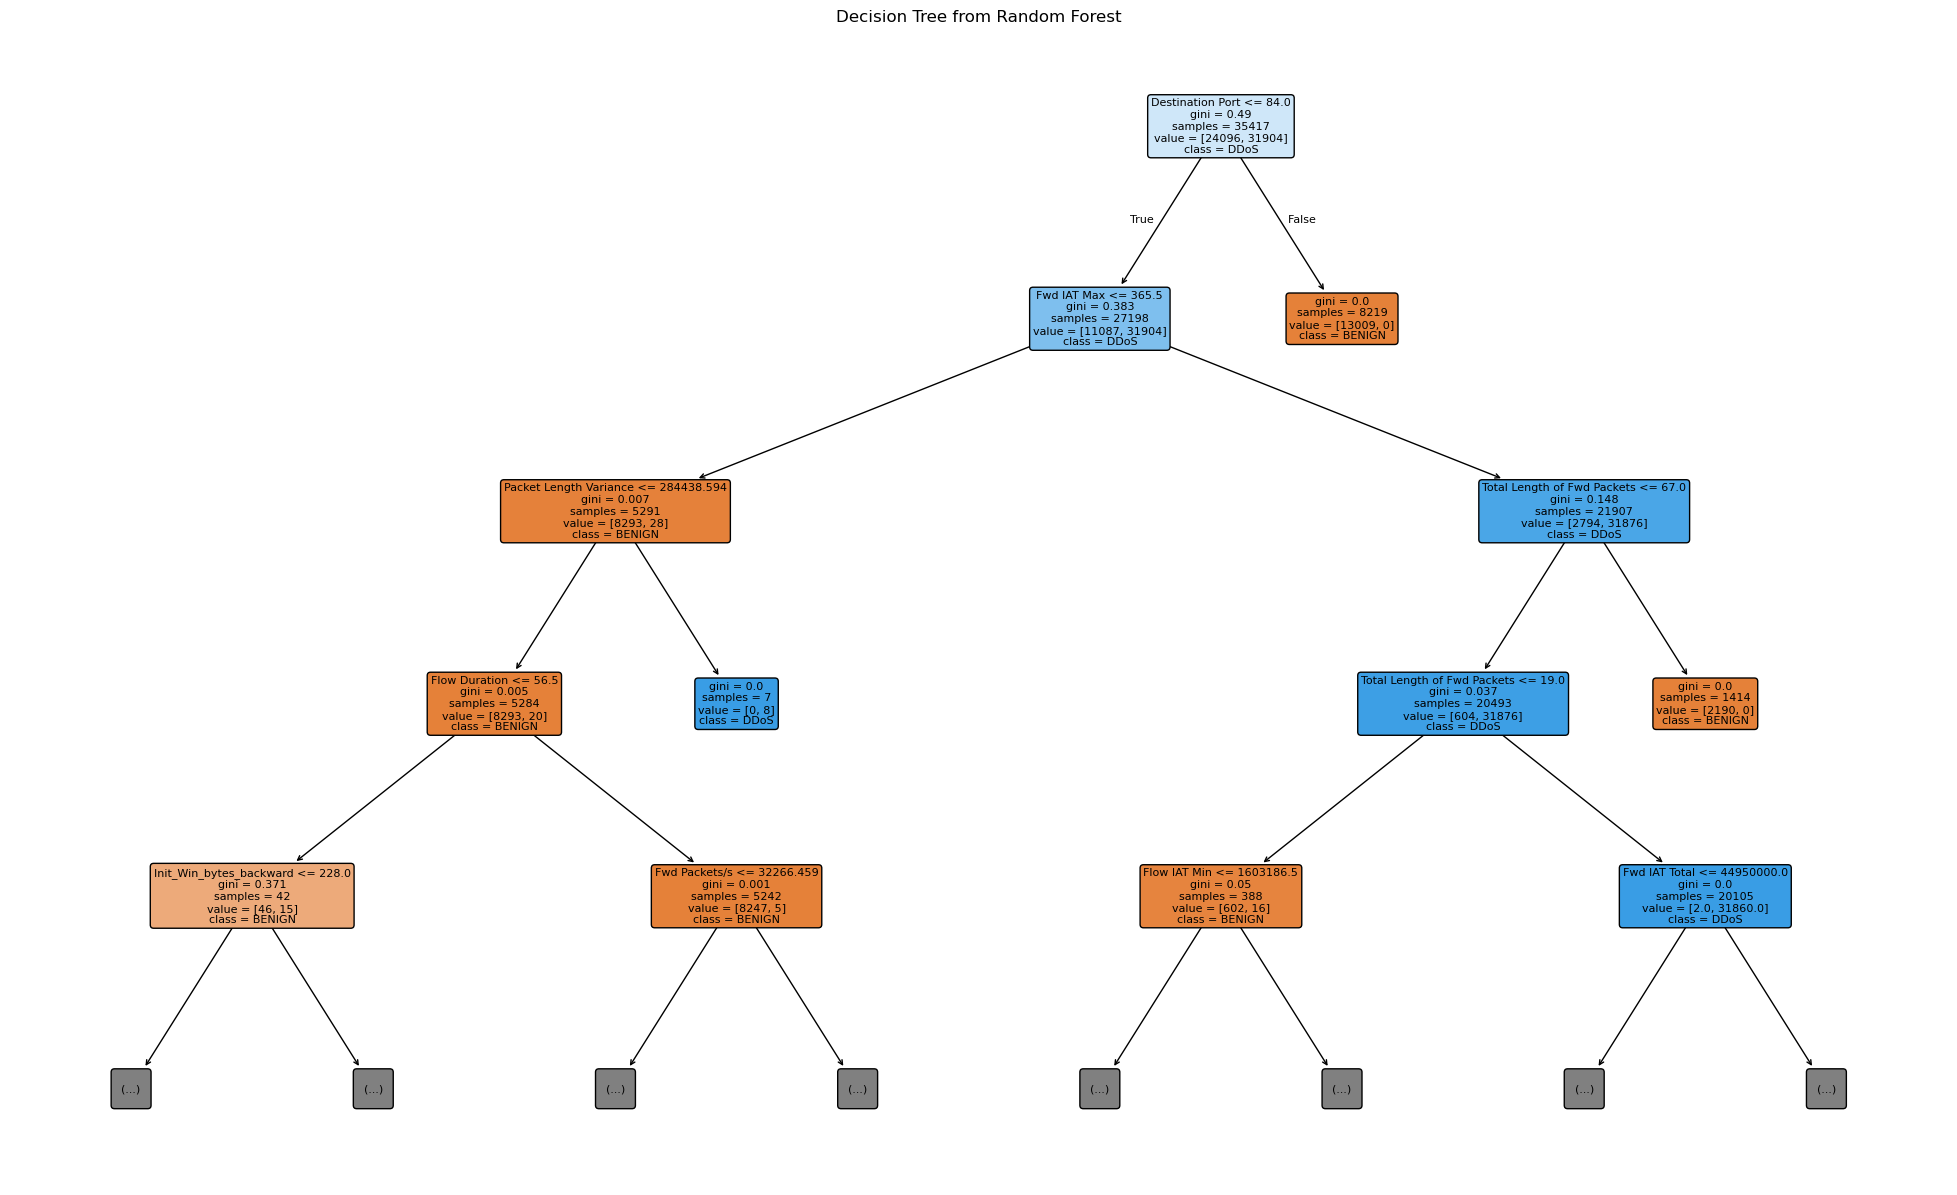

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select the first tree in the forest
tree = model.estimators_[0]

plt.figure(figsize=(25, 15))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['BENIGN', 'DDoS'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # Show only the first 3 levels
)

plt.title("Decision Tree from Random Forest")
plt.show()

In [29]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.9999
Model Accuracy: 99.99%


In [32]:
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 0.9999
Testing Accuracy : 0.9999


In [33]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("Cross-validation accuracies:", scores)
print("Mean CV Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-validation accuracies: [0.999625  0.9999375 0.9995    0.9998125 0.9996875]
Mean CV Accuracy: 0.9997125
Standard Deviation: 0.0001510380746699293


<Figure size 600x600 with 0 Axes>

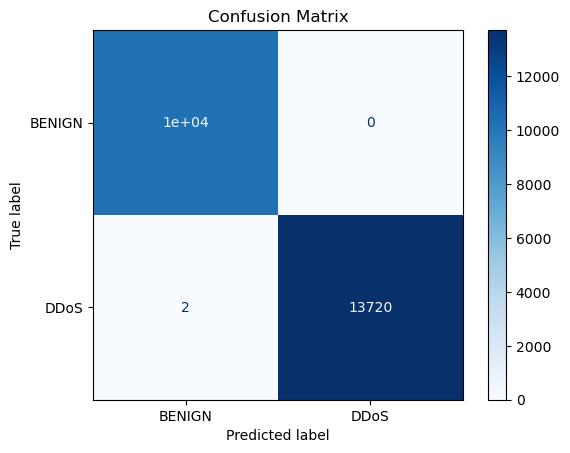

In [34]:
#confusion matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['BENIGN', 'DDoS']
)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

AUC Score: 0.9999999716381888


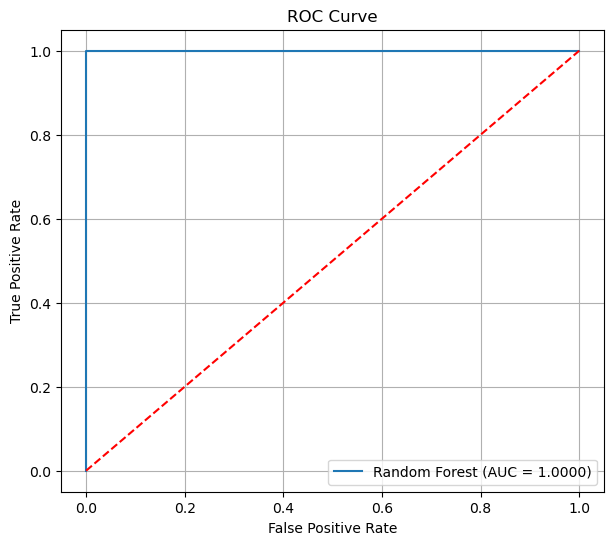

In [35]:
#2. ROC Curve and AUC Score
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [37]:
#4. Cross-Validation Results Table
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cv_table = pd.DataFrame({
    'Fold': ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5'],
    'Accuracy': cv_scores
})

print(cv_table)

print("\nMean Accuracy :", cv_scores.mean())
print("Std Deviation :", cv_scores.std())

     Fold  Accuracy
0  Fold 1  0.999625
1  Fold 2  0.999938
2  Fold 3  0.999500
3  Fold 4  0.999812
4  Fold 5  0.999687

Mean Accuracy : 0.9997125
Std Deviation : 0.0001510380746699293


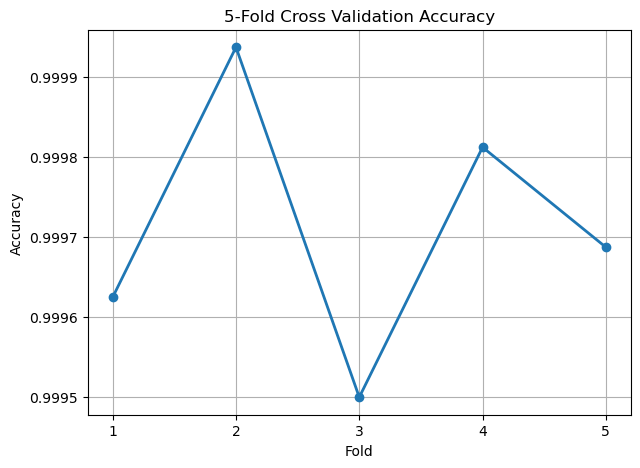

In [38]:
#5. Cross-Validation Accuracy Graph
plt.figure(figsize=(7,5))

plt.plot(
    range(1,6),
    cv_scores,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,6))

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("5-Fold Cross Validation Accuracy")

plt.grid(True)

plt.show()

Training Accuracy : 0.9998928571428571
Testing Accuracy : 0.9999166666666667


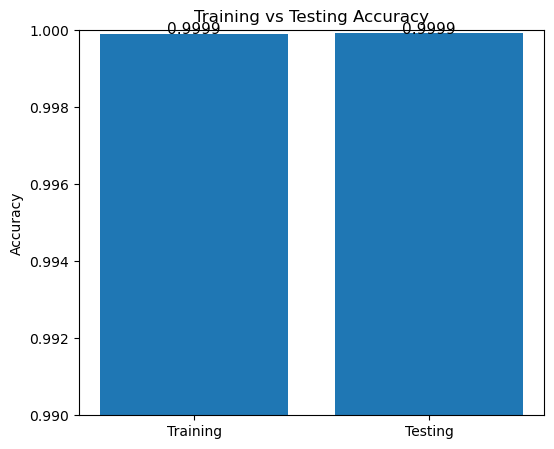

In [39]:
#6. Training vs Testing Accuracy Comparison
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)

plt.figure(figsize=(6,5))

plt.bar(
    ['Training','Testing'],
    [train_acc,test_acc]
)

plt.ylim(0.99,1.0)

for i,v in enumerate([train_acc,test_acc]):
    plt.text(i,v,f"{v:.4f}",ha='center',fontsize=11)

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.show()

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11410
           1       1.00      1.00      1.00     18590

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


Top 15 Important Features (XGBoost):
                        Feature  Importance
66       Init_Win_bytes_forward    0.506247
0              Destination Port    0.358149
4   Total Length of Fwd Packets    0.075076
6         Fwd Packet Length Max    0.033150
67      Init_Win_bytes_backward    0.014229
26                 Bwd IAT Mean    0.001950
37                Bwd Packets/s    0.001441
2             Total Fwd Packets    0.001172
15               Flow Packets/s    0.000842
17                 Flow IAT Std    0.000697
13        Bwd Packet Length Std    0.000619
34            Fwd Header Length    0.000591
21                 Fwd IAT Mean 

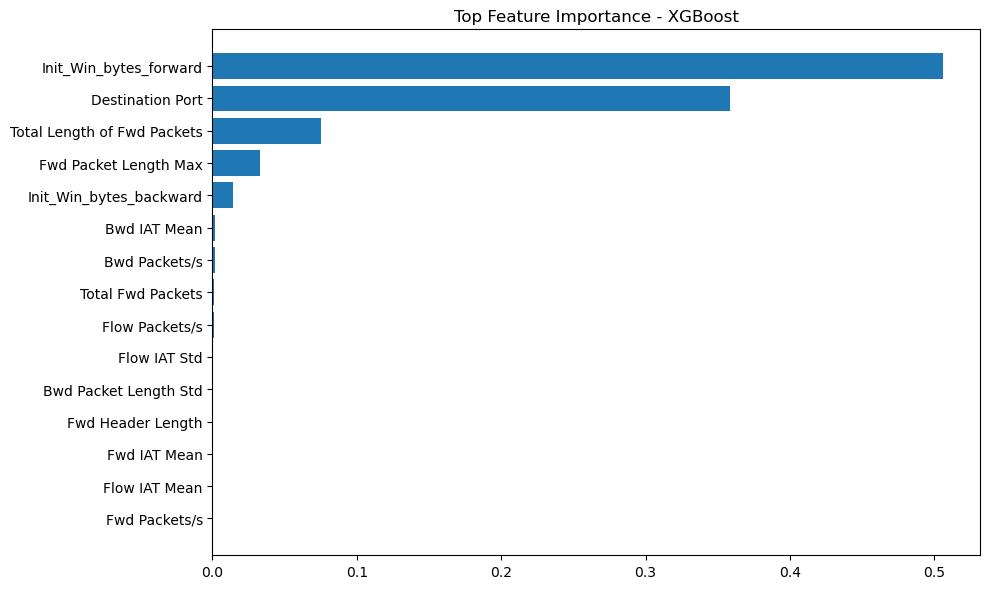

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load
df = pd.read_csv("03_Data/processed/cleaned_ddos.csv", low_memory=True, nrows=100000)

df.columns = df.columns.str.strip()
df.rename(columns={' Label': 'Label'}, inplace=True)

# Handle inf
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

df['Label_Binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.select_dtypes(include=['number']).drop(columns=['Label_Binary'], errors='ignore')
y = df['Label_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
# XGBoost Model
model = XGBClassifier(n_estimators=50, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

print("\nTop 15 Important Features (XGBoost):")
print(feature_importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Top Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.6 MB/s eta 0:00:26
    --------------------------------------- 1.3/69.5 MB 2.9 MB/s eta 0:00:24
   - -------------------------------------- 2.6/69.5 MB 3.9 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/69.5 MB 4.2 MB/s eta 0:00:16
   -- ------------------------------------- 3.9/69.5 MB 3.7 MB/s eta 0:00:18
   -- ------------------------------------- 4.2/69.5 MB 3.7 MB/s eta 0:00:18
   -- ------------------------------------- 5.0/69.5 MB 3.3 MB/s eta 0:00:20
   --- ------------------------------------ 5.8/69.5 MB 3.4 MB/s eta 0:00:19
   --- ------------------------------------ 6.8/69.5 MB 3.5 MB/s eta 0:00:18
   ---- ----------------------------------- 8.7/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 10.2/69.5 MB 4.4 MB/s eta 0:00:14
   ------ --